**IMPORTS & CONFIGURATION**


In [22]:
# ═══ Standard Libraries ═══
import pandas as pd
import numpy as np
import pickle
from pathlib import Path

# ═══ Machine Learning ═══
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_curve, 
    auc, 
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

# ═══ Visualization ═══
import matplotlib.pyplot as plt
import seaborn as sns

# ═══ Warnings ═══
import warnings
warnings.filterwarnings('ignore')

# ═══ Display Settings ═══
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All imports successful!
NumPy version: 2.1.3
Pandas version: 2.2.3


**PROJECT CONFIGURATION**

In [23]:
# ═══ Configuration ═══
CONFIG = {
    'RANDOM_STATE': 42,
    'CV_FOLDS': 5,
    'TEST_SIZE': 0.2,
    'RANDOM_SEED': 42
}

# ═══ File Paths ═══
PATHS = {
    'train_data': '../data/processed/train.csv',
    'test_data': '../data/processed/test.csv',
    'outputs': '../outputs'
}

# ═══ Model Names ═══
MODEL_NAMES = {
    'nb': 'Naive Bayes',
    'lr': 'Logistic Regression',
    'svm': 'Support Vector Machine'
}

# ═══ Create Output Directory ═══
Path(PATHS['outputs']).mkdir(parents=True, exist_ok=True)

print("="*60)
print("CONFIGURATION LOADED")
print("="*60)
print(f"Random State: {CONFIG['RANDOM_STATE']}")
print(f"CV Folds: {CONFIG['CV_FOLDS']}")
print(f"Output Directory: {PATHS['outputs']}")

CONFIGURATION LOADED
Random State: 42
CV Folds: 5
Output Directory: ../outputs


**DATA LOADING & INSPECTION**

In [24]:
# ═══ Load Data ═══
train = pd.read_csv(PATHS['train_data'])
test = pd.read_csv(PATHS['test_data'])

# ═══ Data Inspection ═══
print("\n" + "="*60)
print("DATA LOADING SUMMARY")
print("="*60)

print(f"\n Training Data:")
print(f"  Shape: {train.shape}")
print(f"  Columns: {list(train.columns)}")
print(f"  Memory: {train.memory_usage(deep=True).sum() / 1024:.2f} KB")

print(f"\n Testing Data:")
print(f"  Shape: {test.shape}")
print(f"  Columns: {list(test.columns)}")
print(f"  Memory: {test.memory_usage(deep=True).sum() / 1024:.2f} KB")

# ═══ Class Distribution ═══
print(f"\n Class Distribution (Training):")
train_counts = train['status'].value_counts()
for label, count in train_counts.items():
    percentage = (count / len(train)) * 100
    print(f"  {label}: {count} ({percentage:.1f}%)")

print(f"\n Class Distribution (Testing):")
test_counts = test['status'].value_counts()
for label, count in test_counts.items():
    percentage = (count / len(test)) * 100
    print(f"  {label}: {count} ({percentage:.1f}%)")

# ═══ Sample Data ═══
print(f"\n Sample Messages:")
print(train[['cleaned_msg', 'status']].head(2).to_string())


DATA LOADING SUMMARY

 Training Data:
  Shape: (190, 3)
  Columns: ['msg', 'cleaned_msg', 'status']
  Memory: 65.04 KB

 Testing Data:
  Shape: (48, 3)
  Columns: ['msg', 'cleaned_msg', 'status']
  Memory: 16.57 KB

 Class Distribution (Training):
  Genuine: 105 (55.3%)
  Scam: 85 (44.7%)

 Class Distribution (Testing):
  Genuine: 26 (54.2%)
  Scam: 22 (45.8%)

 Sample Messages:
                                                                                                                                         cleaned_msg   status
0  masroof jazz auto reply bina call uthae caller apni masrufiat agah karein rs numtoken day inc tax service lgane liye sub likh numtoken sms karein  Genuine
1                                         government scheme betiyon numtoken milega registration liye apna cnic number otp number phonetoken bhejain     Scam


 **FEATURE EXTRACTION (TF-IDF VECTORIZATION)**

In [25]:
print("\n" + "="*60)
print("TEXT VECTORIZATION (TF-IDF)")
print("="*60)

# ═══ Vectorizer Setup ═══
vectorizer = TfidfVectorizer(
    max_features=1500,        # Top features
    min_df=2,                 # Minimum document frequency
    max_df=0.95,              # Maximum document frequency
    ngram_range=(1, 2),       # Unigrams + Bigrams
    sublinear_tf=True,        # Better scaling
    lowercase=True,           # Already lowercase but ensure
    stop_words=None           # Roman Urdu ke liye custom stopwords nahi
)

# ═══ Fit & Transform ═══
print("\n Fitting vectorizer on training data...")
X_train = vectorizer.fit_transform(train['cleaned_msg'])
print(f"  ✓ Training features shape: {X_train.shape}")
print(f"  ✓ Sparsity: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")

# ═══ Transform Test Data ═══
print("\n Transforming test data...")
X_test = vectorizer.transform(test['cleaned_msg'])
print(f"  ✓ Testing features shape: {X_test.shape}")

# ═══ Target Labels ═══
y_train = train['status']
y_test = test['status']

print(f"\n✓ Target labels encoded")
print(f"  Training labels shape: {y_train.shape}")
print(f"  Testing labels shape: {y_test.shape}")

# ═══ Feature Names ═══
feature_names = vectorizer.get_feature_names_out()
print(f"\n Vocabulary Size: {len(feature_names)}")
print(f"   Sample features: {list(feature_names[:10])}")


TEXT VECTORIZATION (TF-IDF)

 Fitting vectorizer on training data...
  ✓ Training features shape: (190, 535)
  ✓ Sparsity: 96.32%

 Transforming test data...
  ✓ Testing features shape: (48, 535)

✓ Target labels encoded
  Training labels shape: (190,)
  Testing labels shape: (48,)

 Vocabulary Size: 535
   Sample features: ['8171', '8171 sms', 'aaj', 'aap', 'aap account', 'aap allied', 'aap bank', 'aap easypaisa', 'aap faysal', 'aap hbl']


**MODEL 1 - NAIVE BAYES**

In [27]:
print("\n" + "="*80)
print("MODEL 1: NAIVE BAYES (MULTINOMIAL)")
print("="*80)

# ═══ Model Training ═══
print("\n Training Naive Bayes...")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
print(" Training complete!")

# ═══ Predictions ═══
print("\n Making predictions...")
nb_pred_train = nb_model.predict(X_train)
nb_pred_test = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)[:, 1]
print(" Predictions complete!")

# ═══ Accuracies ═══
nb_train_acc = accuracy_score(y_train, nb_pred_train)
nb_test_acc = accuracy_score(y_test, nb_pred_test)
print(f"\n Training Accuracy: {nb_train_acc:.4f} ({nb_train_acc*100:.2f}%)")
print(f" Testing Accuracy: {nb_test_acc:.4f} ({nb_test_acc*100:.2f}%)")

# ═══ Cross-Validation ═══
print("\n Running 5-fold Cross-Validation...")
nb_cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"   CV Scores: {[f'{s:.4f}' for s in nb_cv_scores]}")
print(f"   Mean CV Score: {nb_cv_scores.mean():.4f} ± {nb_cv_scores.std():.4f}")

# ═══ Detailed Metrics ═══
print("\n" + "-"*80)
print("DETAILED EVALUATION - NAIVE BAYES")
print("-"*80)
print(classification_report(y_test, nb_pred_test, zero_division=0))

# ═══ Confusion Matrix ═══
nb_cm = confusion_matrix(y_test, nb_pred_test)
print(f"\nConfusion Matrix:")
print(f"  True Negatives (Genuine, Correctly Classified): {nb_cm[0, 0]}")
print(f"  False Positives (Genuine, Classified as Scam): {nb_cm[0, 1]}")
print(f"  False Negatives (Scam, Classified as Genuine): {nb_cm[1, 0]}")
print(f"  True Positives (Scam, Correctly Classified): {nb_cm[1, 1]}")


nb_precision = precision_score(y_test, nb_pred_test, zero_division=0, pos_label='Scam')
nb_recall = recall_score(y_test, nb_pred_test, zero_division=0, pos_label='Scam')
nb_f1 = f1_score(y_test, nb_pred_test, zero_division=0, pos_label='Scam')
nb_roc_auc = roc_auc_score(y_test, nb_pred_proba)

print(f"\nKey Metrics:")
print(f"  Precision: {nb_precision:.4f} (Scam detection accuracy)")
print(f"  Recall: {nb_recall:.4f} (Scam detection coverage)")
print(f"  F1-Score: {nb_f1:.4f} (Harmonic mean)")
print(f"  ROC-AUC: {nb_roc_auc:.4f} (Discrimination ability)")

# ═══ Store Results ═══
nb_results = {
    'model': nb_model,
    'predictions': nb_pred_test,
    'probabilities': nb_pred_proba,
    'accuracy': nb_test_acc,
    'precision': nb_precision,
    'recall': nb_recall,
    'f1': nb_f1,
    'roc_auc': nb_roc_auc,
    'cv_scores': nb_cv_scores
}

print("\n Naive Bayes complete!")


MODEL 1: NAIVE BAYES (MULTINOMIAL)

 Training Naive Bayes...
 Training complete!

 Making predictions...
 Predictions complete!

 Training Accuracy: 0.9842 (98.42%)
 Testing Accuracy: 0.9792 (97.92%)

 Running 5-fold Cross-Validation...
   CV Scores: ['0.9475', '0.9475', '0.9474', '0.9469', '0.9474']
   Mean CV Score: 0.9473 ± 0.0002

--------------------------------------------------------------------------------
DETAILED EVALUATION - NAIVE BAYES
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98        26
        Scam       1.00      0.95      0.98        22

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48


Confusion Matrix:
  True Negatives (Genuine, Correctly Classified): 26
  False Positives (Genuine, Classified as Scam): 0
  False Negative

**MODEL 2 - LOGISTIC REGRESSION (WITH HYPERPARAMETER TUNING)**

In [28]:
print("\n" + "="*80)
print("MODEL 2: LOGISTIC REGRESSION (WITH HYPERPARAMETER TUNING)")
print("="*80)

# ═══ Hyperparameter Grid ═══
print("\n Setting up hyperparameter grid...")
lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strength
    'solver': ['lbfgs', 'saga'],              # Optimization algorithm
    'max_iter': [1000, 2000]                  # Maximum iterations
}
print(f"   Total combinations: {5 * 2 * 2} = 20")

# ═══ GridSearchCV ═══
print("\n Running GridSearchCV (5-fold)...")
print("   This may take 5-10 seconds...")

lr_grid = GridSearchCV(
    LogisticRegression(random_state=CONFIG['RANDOM_STATE'], n_jobs=-1),
    lr_params,
    cv=CONFIG['CV_FOLDS'],
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train, y_train)
lr_model = lr_grid.best_estimator_

print(" GridSearchCV complete!")
print(f"\n Best Parameters Found:")
for param, value in lr_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"   Best CV Score: {lr_grid.best_score_:.4f}")

# ═══ Predictions ═══
print("\n Making predictions...")
lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]
print(" Predictions complete!")

# ═══ Accuracies ═══
lr_train_acc = accuracy_score(y_train, lr_pred_train)
lr_test_acc = accuracy_score(y_test, lr_pred_test)
print(f"\n Training Accuracy: {lr_train_acc:.4f} ({lr_train_acc*100:.2f}%)")
print(f" Testing Accuracy: {lr_test_acc:.4f} ({lr_test_acc*100:.2f}%)")

# ═══ Cross-Validation ═══
print("\n Cross-Validation with best model...")
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"   CV Scores: {[f'{s:.4f}' for s in lr_cv_scores]}")
print(f"   Mean CV Score: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")

# ═══ Detailed Metrics ═══
print("\n" + "-"*80)
print("DETAILED EVALUATION - LOGISTIC REGRESSION")
print("-"*80)
print(classification_report(y_test, lr_pred_test, zero_division=0))

# ═══ Confusion Matrix ═══
lr_cm = confusion_matrix(y_test, lr_pred_test)
print(f"\nConfusion Matrix:")
print(f"  True Negatives (Genuine, Correctly Classified): {lr_cm[0, 0]}")
print(f"  False Positives (Genuine, Classified as Scam): {lr_cm[0, 1]}")
print(f"  False Negatives (Scam, Classified as Genuine): {lr_cm[1, 0]}")
print(f"  True Positives (Scam, Correctly Classified): {lr_cm[1, 1]}")

lr_precision = precision_score(y_test, lr_pred_test, zero_division=0, pos_label='Scam')
lr_recall = recall_score(y_test, lr_pred_test, zero_division=0, pos_label='Scam')
lr_f1 = f1_score(y_test, lr_pred_test, zero_division=0, pos_label='Scam')
lr_roc_auc = roc_auc_score(y_test, lr_pred_proba)

print(f"\nKey Metrics:")
print(f"  Precision: {lr_precision:.4f} (Scam detection accuracy)")
print(f"  Recall: {lr_recall:.4f} (Scam detection coverage)")
print(f"  F1-Score: {lr_f1:.4f} (Harmonic mean)")
print(f"  ROC-AUC: {lr_roc_auc:.4f} (Discrimination ability)")

# ═══ Store Results ═══
lr_results = {
    'model': lr_model,
    'predictions': lr_pred_test,
    'probabilities': lr_pred_proba,
    'accuracy': lr_test_acc,
    'precision': lr_precision,
    'recall': lr_recall,
    'f1': lr_f1,
    'roc_auc': lr_roc_auc,
    'cv_scores': lr_cv_scores
}

print("\n Logistic Regression complete!")


MODEL 2: LOGISTIC REGRESSION (WITH HYPERPARAMETER TUNING)

 Setting up hyperparameter grid...
   Total combinations: 20 = 20

 Running GridSearchCV (5-fold)...
   This may take 5-10 seconds...
 GridSearchCV complete!

 Best Parameters Found:
   C: 1
   max_iter: 1000
   solver: saga
   Best CV Score: 0.9631

 Making predictions...
 Predictions complete!

 Training Accuracy: 0.9842 (98.42%)
 Testing Accuracy: 0.9792 (97.92%)

 Cross-Validation with best model...
   CV Scores: ['0.9737', '0.9475', '1.0000', '0.9469', '0.9474']
   Mean CV Score: 0.9631 ± 0.0211

--------------------------------------------------------------------------------
DETAILED EVALUATION - LOGISTIC REGRESSION
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98        26
        Scam       1.00      0.95      0.98        22

    accuracy                           0.98        48
   macro av

**MODEL 3 - SUPPORT VECTOR MACHINE (WITH HYPERPARAMETER TUNING)**

In [29]:
print("\n" + "="*80)
print("MODEL 3: SUPPORT VECTOR MACHINE (WITH HYPERPARAMETER TUNING)")
print("="*80)

# ═══ Hyperparameter Grid ═══
print("\n Setting up hyperparameter grid...")
svm_params = {
    'C': [0.1, 1, 10],                    # Regularization
    'kernel': ['linear', 'rbf'],          # Kernel type
    'gamma': ['scale', 'auto']            # Gamma parameter
}
print(f"   Total combinations: {3 * 2 * 2} = 12")

# ═══ GridSearchCV ═══
print("\n Running GridSearchCV (5-fold)...")
print("   This may take 10-20 seconds (SVM is slower)...")

svm_grid = GridSearchCV(
    SVC(random_state=CONFIG['RANDOM_STATE'], probability=True),  
    svm_params,
    cv=CONFIG['CV_FOLDS'],
    scoring='f1_weighted',
    n_jobs=-1,  # n_jobs only for GridSearchCV, not for SVC
    verbose=0
)

svm_grid.fit(X_train, y_train)
svm_model = svm_grid.best_estimator_

print(" GridSearchCV complete!")
print(f"\n Best Parameters Found:")
for param, value in svm_grid.best_params_.items():
    print(f"   {param}: {value}")
print(f"   Best CV Score: {svm_grid.best_score_:.4f}")

# ═══ Predictions ═══
print("\n Making predictions...")
svm_pred_train = svm_model.predict(X_train)
svm_pred_test = svm_model.predict(X_test)
svm_pred_proba = svm_model.predict_proba(X_test)[:, 1]
print(" Predictions complete!")

# ═══ Accuracies ═══
svm_train_acc = accuracy_score(y_train, svm_pred_train)
svm_test_acc = accuracy_score(y_test, svm_pred_test)
print(f"\n Training Accuracy: {svm_train_acc:.4f} ({svm_train_acc*100:.2f}%)")
print(f" Testing Accuracy: {svm_test_acc:.4f} ({svm_test_acc*100:.2f}%)")

# ═══ Cross-Validation ═══
print("\n Cross-Validation with best model...")
svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='f1_weighted')
print(f"   CV Scores: {[f'{s:.4f}' for s in svm_cv_scores]}")
print(f"   Mean CV Score: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}")

# ═══ Detailed Metrics ═══
print("\n" + "-"*80)
print("DETAILED EVALUATION - SUPPORT VECTOR MACHINE")
print("-"*80)
print(classification_report(y_test, svm_pred_test, zero_division=0))

# ═══ Confusion Matrix ═══
svm_cm = confusion_matrix(y_test, svm_pred_test)
print(f"\nConfusion Matrix:")
print(f"  True Negatives (Genuine, Correctly Classified): {svm_cm[0, 0]}")
print(f"  False Positives (Genuine, Classified as Scam): {svm_cm[0, 1]}")
print(f"  False Negatives (Scam, Classified as Genuine): {svm_cm[1, 0]}")
print(f"  True Positives (Scam, Correctly Classified): {svm_cm[1, 1]}")


svm_precision = precision_score(y_test, svm_pred_test, zero_division=0, pos_label='Scam')
svm_recall = recall_score(y_test, svm_pred_test, zero_division=0, pos_label='Scam')
svm_f1 = f1_score(y_test, svm_pred_test, zero_division=0, pos_label='Scam')
svm_roc_auc = roc_auc_score(y_test, svm_pred_proba)

print(f"\nKey Metrics:")
print(f"  Precision: {svm_precision:.4f} (Scam detection accuracy)")
print(f"  Recall: {svm_recall:.4f} (Scam detection coverage)")
print(f"  F1-Score: {svm_f1:.4f} (Harmonic mean)")
print(f"  ROC-AUC: {svm_roc_auc:.4f} (Discrimination ability)")

# ═══ Store Results ═══
svm_results = {
    'model': svm_model,
    'predictions': svm_pred_test,
    'probabilities': svm_pred_proba,
    'accuracy': svm_test_acc,
    'precision': svm_precision,
    'recall': svm_recall,
    'f1': svm_f1,
    'roc_auc': svm_roc_auc,
    'cv_scores': svm_cv_scores
}

print("\n Support Vector Machine complete!")


MODEL 3: SUPPORT VECTOR MACHINE (WITH HYPERPARAMETER TUNING)

 Setting up hyperparameter grid...
   Total combinations: 12 = 12

 Running GridSearchCV (5-fold)...
   This may take 10-20 seconds (SVM is slower)...
 GridSearchCV complete!

 Best Parameters Found:
   C: 1
   gamma: scale
   kernel: linear
   Best CV Score: 0.9526

 Making predictions...
 Predictions complete!

 Training Accuracy: 0.9789 (97.89%)
 Testing Accuracy: 0.9792 (97.92%)

 Cross-Validation with best model...
   CV Scores: ['0.9475', '0.9475', '0.9737', '0.9469', '0.9474']
   Mean CV Score: 0.9526 ± 0.0106

--------------------------------------------------------------------------------
DETAILED EVALUATION - SUPPORT VECTOR MACHINE
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Genuine       0.96      1.00      0.98        26
        Scam       1.00      0.95      0.98        22

    accuracy                           0.9

**COMPREHENSIVE MODEL COMPARISON**

In [30]:
print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*100)

# ═══ Create Comparison DataFrame ═══
comparison_data = [
    {
        'Model': 'Naive Bayes',
        'Accuracy': nb_results['accuracy'],
        'Precision': nb_results['precision'],
        'Recall': nb_results['recall'],
        'F1-Score': nb_results['f1'],
        'ROC-AUC': nb_results['roc_auc'],
        'CV Mean': nb_results['cv_scores'].mean(),
        'CV Std': nb_results['cv_scores'].std()
    },
    {
        'Model': 'Logistic Regression',
        'Accuracy': lr_results['accuracy'],
        'Precision': lr_results['precision'],
        'Recall': lr_results['recall'],
        'F1-Score': lr_results['f1'],
        'ROC-AUC': lr_results['roc_auc'],
        'CV Mean': lr_results['cv_scores'].mean(),
        'CV Std': lr_results['cv_scores'].std()
    },
    {
        'Model': 'Support Vector Machine',
        'Accuracy': svm_results['accuracy'],
        'Precision': svm_results['precision'],
        'Recall': svm_results['recall'],
        'F1-Score': svm_results['f1'],
        'ROC-AUC': svm_results['roc_auc'],
        'CV Mean': svm_results['cv_scores'].mean(),
        'CV Std': svm_results['cv_scores'].std()
    }
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

# ═══ Display Table ═══
print("\n" + comparison_df.to_string(index=False))

# ═══ Best Model ═══
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1-Score']

print("\n" + "="*100)
print(f" BEST MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")
print("="*100)

# ═══ Save to CSV ═══
comparison_df.to_csv(f"{PATHS['outputs']}/01_model_comparison_table.csv", index=False)
print(f"\n Comparison table saved to: 01_model_comparison_table.csv")


COMPREHENSIVE MODEL COMPARISON

                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV Mean   CV Std
           Naive Bayes  0.979167        1.0 0.954545  0.976744 0.994755 0.947337 0.000219
   Logistic Regression  0.979167        1.0 0.954545  0.976744 0.996503 0.963108 0.021104
Support Vector Machine  0.979167        1.0 0.954545  0.976744 0.993007 0.952611 0.010566

 BEST MODEL: Naive Bayes
   F1-Score: 0.9767

 Comparison table saved to: 01_model_comparison_table.csv


**CONFUSION MATRICES - ALL 3 MODELS**


GENERATING CONFUSION MATRICES
 Saved: 02_confusion_matrices.png


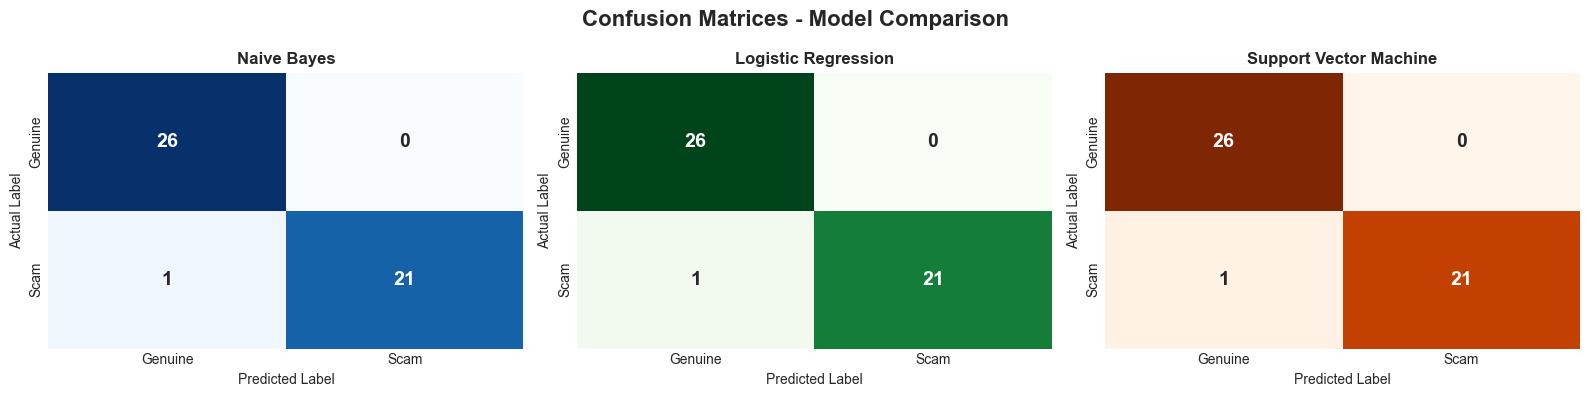


CONFUSION MATRIX INTERPRETATION:
------------------------------------------------------------
True Negatives (TN):   Genuine SMS, correctly classified
False Positives (FP):  Genuine SMS, wrongly classified as Scam
False Negatives (FN):  Scam SMS, wrongly classified as Genuine
True Positives (TP):   Scam SMS, correctly classified

Best scenario: High TN and TP, Low FP and FN


In [31]:
print("\n" + "="*80)
print("GENERATING CONFUSION MATRICES")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Confusion Matrices - Model Comparison', fontsize=16, fontweight='bold')

# ═══ Color Palettes ═══
colormaps = ['Blues', 'Greens', 'Oranges']
model_data = [
    ('Naive Bayes', nb_results['predictions'], axes[0]),
    ('Logistic Regression', lr_results['predictions'], axes[1]),
    ('Support Vector Machine', svm_results['predictions'], axes[2])
]

# ═══ Plot Each Model ═══
for (model_name, predictions, ax), cmap in zip(model_data, colormaps):
    cm = confusion_matrix(y_test, predictions)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        cbar=False,
        xticklabels=['Genuine', 'Scam'],
        yticklabels=['Genuine', 'Scam'],
        ax=ax,
        annot_kws={'size': 14, 'weight': 'bold'}
    )
    
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.savefig(f"{PATHS['outputs']}/02_confusion_matrices.png", dpi=300, bbox_inches='tight')
print(" Saved: 02_confusion_matrices.png")
plt.show()

# ═══ Interpretation ═══
print("\nCONFUSION MATRIX INTERPRETATION:")
print("-" * 60)
print("True Negatives (TN):   Genuine SMS, correctly classified")
print("False Positives (FP):  Genuine SMS, wrongly classified as Scam")
print("False Negatives (FN):  Scam SMS, wrongly classified as Genuine")
print("True Positives (TP):   Scam SMS, correctly classified")
print("\nBest scenario: High TN and TP, Low FP and FN")

**PERFORMANCE METRICS - 4 SUBPLOT COMPARISON**


GENERATING PERFORMANCE METRICS CHARTS
✓ Saved: 03_performance_metrics_comparison.png


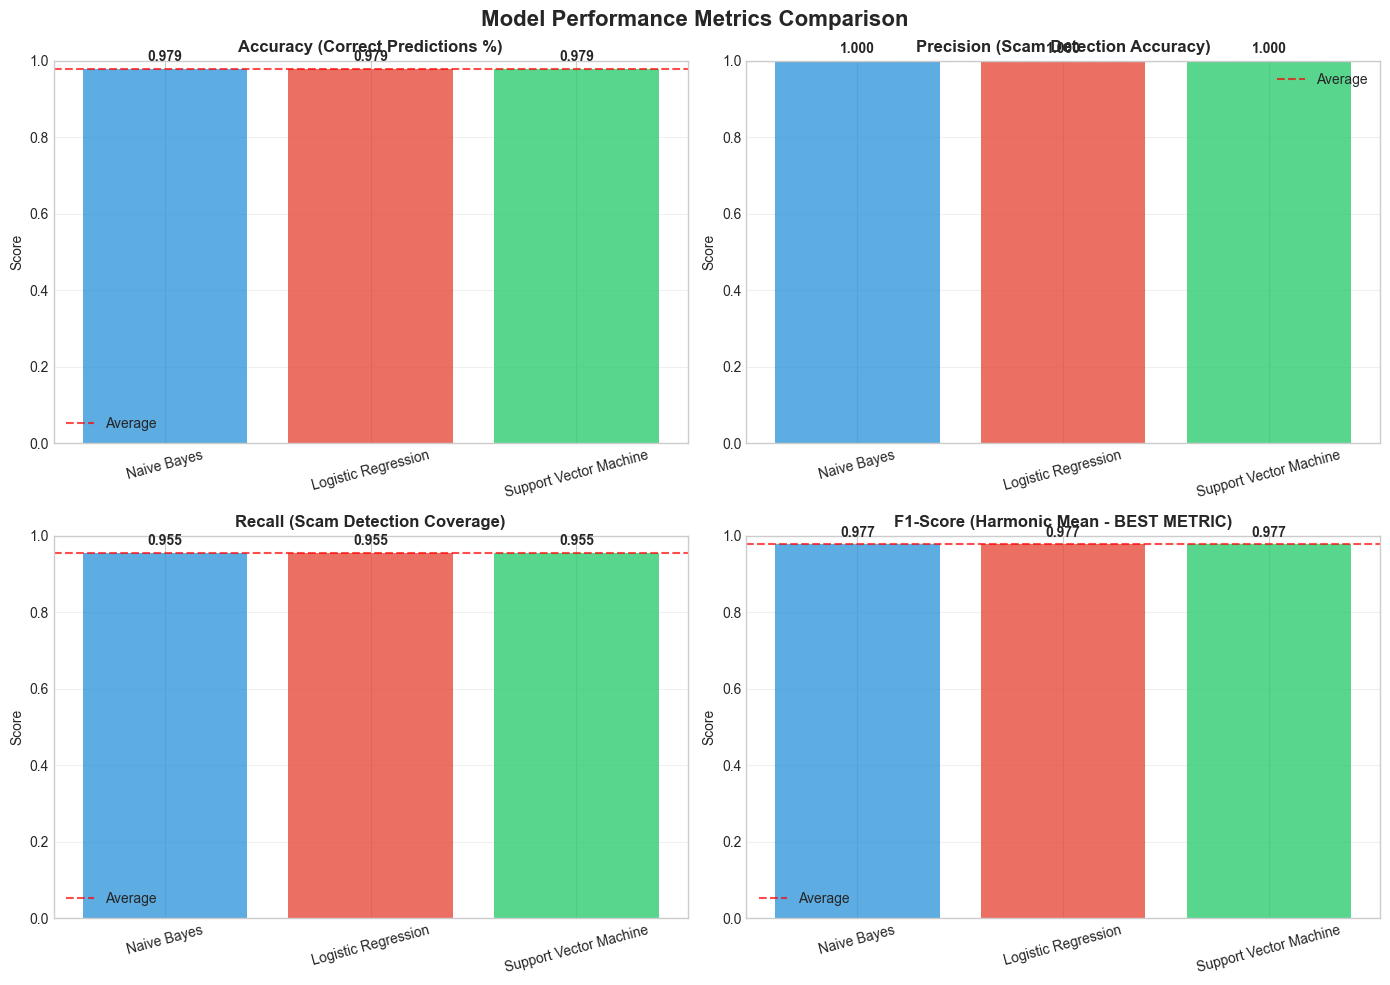


METRIC EXPLANATIONS:
------------------------------------------------------------
• Accuracy: % of correct predictions (both Genuine & Scam)
• Precision: Of predicted Scams, how many are actually Scam
• Recall: Of actual Scams, how many did we catch
• F1-Score: Balance between Precision & Recall (best metric)


In [32]:
print("\n" + "="*80)
print("GENERATING PERFORMANCE METRICS CHARTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')

# ═══ Data ═══
models = comparison_df['Model'].values
metrics_data = {
    'Accuracy': comparison_df['Accuracy'].values,
    'Precision': comparison_df['Precision'].values,
    'Recall': comparison_df['Recall'].values,
    'F1-Score': comparison_df['F1-Score'].values
}

colors_bar = ['#3498db', '#e74c3c', '#2ecc71']

# ═══ CHART 1: ACCURACY ═══
axes[0, 0].bar(models, metrics_data['Accuracy'], color=colors_bar, alpha=0.8)
axes[0, 0].set_title('Accuracy (Correct Predictions %)', fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].axhline(y=metrics_data['Accuracy'].mean(), color='red', linestyle='--', 
                   label='Average', alpha=0.7)
for i, v in enumerate(metrics_data['Accuracy']):
    axes[0, 0].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=15)

# ═══ CHART 2: PRECISION ═══
axes[0, 1].bar(models, metrics_data['Precision'], color=colors_bar, alpha=0.8)
axes[0, 1].set_title('Precision (Scam Detection Accuracy)', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].axhline(y=metrics_data['Precision'].mean(), color='red', linestyle='--', 
                   label='Average', alpha=0.7)
for i, v in enumerate(metrics_data['Precision']):
    axes[0, 1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=15)

# ═══ CHART 3: RECALL ═══
axes[1, 0].bar(models, metrics_data['Recall'], color=colors_bar, alpha=0.8)
axes[1, 0].set_title('Recall (Scam Detection Coverage)', fontweight='bold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].axhline(y=metrics_data['Recall'].mean(), color='red', linestyle='--', 
                   label='Average', alpha=0.7)
for i, v in enumerate(metrics_data['Recall']):
    axes[1, 0].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=15)

# ═══ CHART 4: F1-SCORE ═══
axes[1, 1].bar(models, metrics_data['F1-Score'], color=colors_bar, alpha=0.8)
axes[1, 1].set_title('F1-Score (Harmonic Mean - BEST METRIC)', fontweight='bold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].axhline(y=metrics_data['F1-Score'].mean(), color='red', linestyle='--', 
                   label='Average', alpha=0.7)
for i, v in enumerate(metrics_data['F1-Score']):
    axes[1, 1].text(i, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f"{PATHS['outputs']}/03_performance_metrics_comparison.png", 
            dpi=300, bbox_inches='tight')
print("✓ Saved: 03_performance_metrics_comparison.png")
plt.show()

# ═══ Metric Explanations ═══
print("\nMETRIC EXPLANATIONS:")
print("-" * 60)
print("• Accuracy: % of correct predictions (both Genuine & Scam)")
print("• Precision: Of predicted Scams, how many are actually Scam")
print("• Recall: Of actual Scams, how many did we catch")
print("• F1-Score: Balance between Precision & Recall (best metric)")

**ROC CURVES - ALL 3 MODELS OVERLAPPED**


GENERATING ROC CURVES
Saved: 04_roc_curves.png


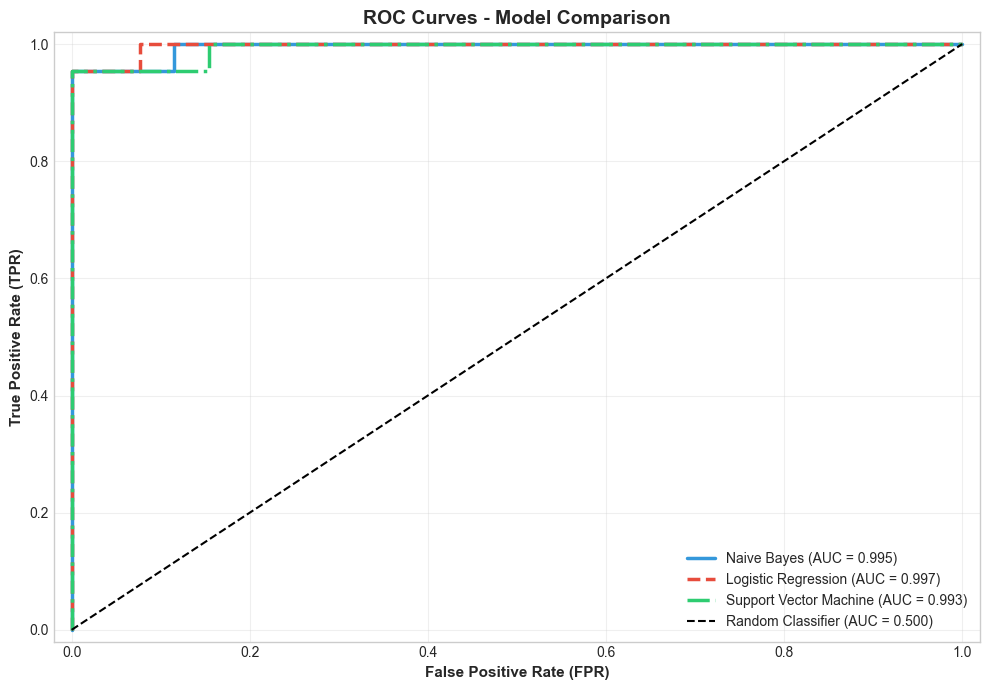


ROC CURVE INTERPRETATION:
------------------------------------------------------------
• Higher AUC = Better discrimination between Scam & Genuine
• AUC = 1.0: Perfect classifier
• AUC = 0.5: Random classifier (no discriminative power)
• AUC > 0.8: Excellent
• AUC > 0.9: Outstanding


In [33]:
print("\n" + "="*80)
print("GENERATING ROC CURVES")
print("="*80)

plt.figure(figsize=(10, 7))

# ═══ ROC Data ═══
roc_data = [
    ('Naive Bayes', nb_results['probabilities'], '#3498db', '-'),
    ('Logistic Regression', lr_results['probabilities'], '#e74c3c', '--'),
    ('Support Vector Machine', svm_results['probabilities'], '#2ecc71', '-.')
]


for model_name, probabilities, color, linestyle in roc_data:
    
    fpr, tpr, _ = roc_curve(y_test, probabilities, pos_label='Scam')
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linestyle=linestyle, linewidth=2.5,
             label=f'{model_name} (AUC = {roc_auc:.3f})')

# ═══ Diagonal Line (Random Classifier) ═══
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')

# ═══ Formatting ═══
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (FPR)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=11, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{PATHS['outputs']}/04_roc_curves.png", dpi=300, bbox_inches='tight')
print("Saved: 04_roc_curves.png")
plt.show()

print("\nROC CURVE INTERPRETATION:")
print("-" * 60)
print("• Higher AUC = Better discrimination between Scam & Genuine")
print("• AUC = 1.0: Perfect classifier")
print("• AUC = 0.5: Random classifier (no discriminative power)")
print("• AUC > 0.8: Excellent")
print("• AUC > 0.9: Outstanding")

**MODEL COMPARISON HEATMAP**


GENERATING MODEL COMPARISON HEATMAP
 Saved: 05_model_comparison_heatmap.png


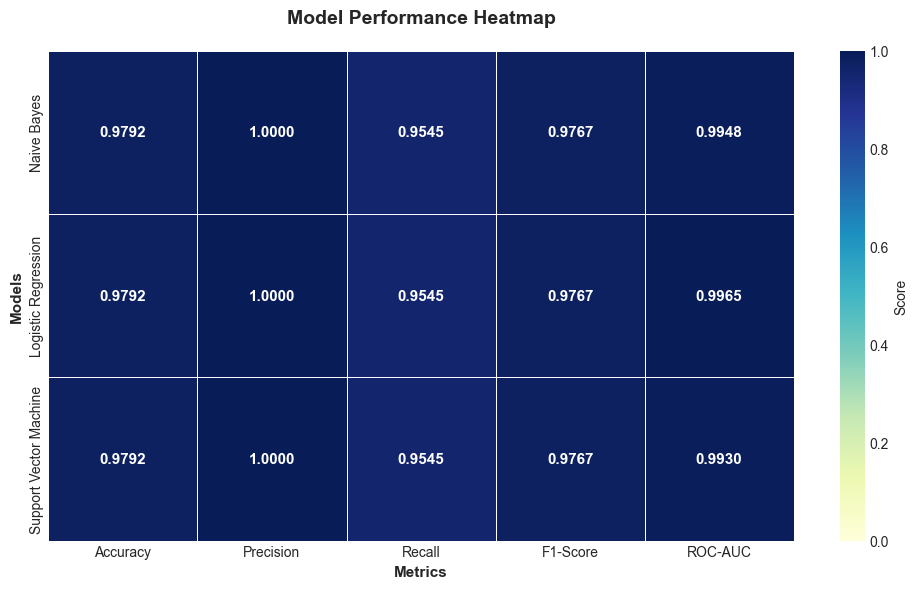


HEATMAP COLOR INTERPRETATION:
------------------------------------------------------------
• Darker blue = Higher score (better)
• Lighter blue = Lower score


In [34]:
print("\n" + "="*80)
print("GENERATING MODEL COMPARISON HEATMAP")
print("="*80)

# ═══ Prepare Data ═══
heatmap_data = comparison_df.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
]

# ═══ Plot ═══
plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Score'},
    linewidths=0.5,
    annot_kws={'size': 11, 'weight': 'bold'},
    vmin=0,
    vmax=1
)

plt.title('Model Performance Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Metrics', fontsize=11, fontweight='bold')
plt.ylabel('Models', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PATHS['outputs']}/05_model_comparison_heatmap.png", 
            dpi=300, bbox_inches='tight')
print(" Saved: 05_model_comparison_heatmap.png")
plt.show()

print("\nHEATMAP COLOR INTERPRETATION:")
print("-" * 60)
print("• Darker blue = Higher score (better)")
print("• Lighter blue = Lower score")

**CROSS-VALIDATION SCORES ANALYSIS**


CROSS-VALIDATION ANALYSIS
 Saved: 06_cross_validation_analysis.png


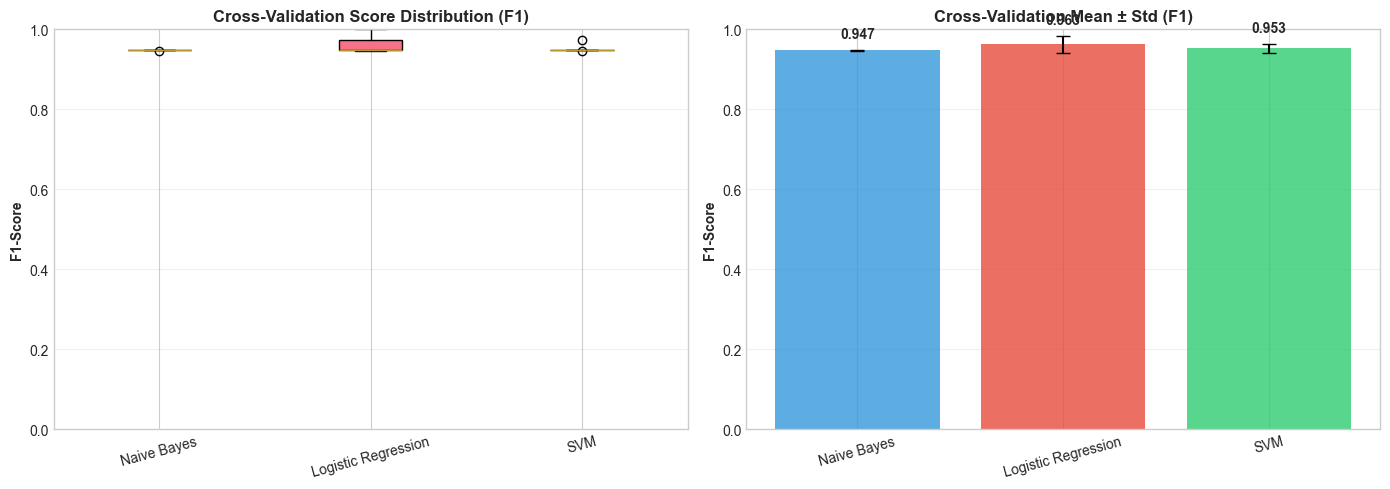


CROSS-VALIDATION SUMMARY:
--------------------------------------------------------------------------------
Naive Bayes:
  Scores: ['0.9475', '0.9475', '0.9474', '0.9469', '0.9474']
  Mean: 0.9473
  Std: 0.0002
  Min: 0.9469, Max: 0.9475

Logistic Regression:
  Scores: ['0.9737', '0.9475', '1.0000', '0.9469', '0.9474']
  Mean: 0.9631
  Std: 0.0211
  Min: 0.9469, Max: 1.0000

SVM:
  Scores: ['0.9475', '0.9475', '0.9737', '0.9469', '0.9474']
  Mean: 0.9526
  Std: 0.0106
  Min: 0.9469, Max: 0.9737



In [35]:
print("\n" + "="*80)
print("CROSS-VALIDATION ANALYSIS")
print("="*80)

# ═══ Prepare CV Data ═══
cv_scores_data = {
    'Naive Bayes': nb_results['cv_scores'],
    'Logistic Regression': lr_results['cv_scores'],
    'SVM': svm_results['cv_scores']
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ═══ Box Plot ═══
box_data = list(cv_scores_data.values())
ax1.boxplot(box_data, labels=cv_scores_data.keys(), patch_artist=True)
ax1.set_title('Cross-Validation Score Distribution (F1)', fontweight='bold')
ax1.set_ylabel('F1-Score', fontweight='bold')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=15)

# ═══ Mean ± Std Bar Chart ═══
means = [scores.mean() for scores in cv_scores_data.values()]
stds = [scores.std() for scores in cv_scores_data.values()]
models_list = list(cv_scores_data.keys())

ax2.bar(models_list, means, yerr=stds, capsize=5, color=['#3498db', '#e74c3c', '#2ecc71'], 
        alpha=0.8)
ax2.set_title('Cross-Validation Mean ± Std (F1)', fontweight='bold')
ax2.set_ylabel('F1-Score', fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)

for i, (mean, std) in enumerate(zip(means, stds)):
    ax2.text(i, mean+std+0.03, f'{mean:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PATHS['outputs']}/06_cross_validation_analysis.png", 
            dpi=300, bbox_inches='tight')
print(" Saved: 06_cross_validation_analysis.png")
plt.show()

print("\nCROSS-VALIDATION SUMMARY:")
print("-" * 80)
for model_name, scores in cv_scores_data.items():
    print(f"{model_name}:")
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean: {scores.mean():.4f}")
    print(f"  Std: {scores.std():.4f}")
    print(f"  Min: {scores.min():.4f}, Max: {scores.max():.4f}")
    print()

**MODEL SAVING & PERSISTENCE**

In [36]:
print("\n" + "="*80)
print("SAVING MODELS & ARTIFACTS")
print("="*80)

# ═══ Save Models ═══
models_to_save = {
    'nb_model.pkl': nb_results['model'],
    'lr_model.pkl': lr_results['model'],
    'svm_model.pkl': svm_results['model']
}

print("\n Saving trained models...")
for filename, model in models_to_save.items():
    filepath = f"{PATHS['outputs']}/{filename}"
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"   {filename}")

# ═══ Save Vectorizer ═══
print("\n Saving vectorizer...")
vectorizer_path = f"{PATHS['outputs']}/vectorizer.pkl"
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)
print(f"  vectorizer.pkl")

# ═══ Save Metrics ═══
print("\n Saving metrics summary...")
comparison_df.to_csv(f"{PATHS['outputs']}/metrics_summary.csv", index=False)
print(f"   metrics_summary.csv")

# ═══ Summary ═══
print("\n" + "="*80)
print(" ALL MODELS SAVED SUCCESSFULLY!")
print("="*80)
print(f"\n Output files in: {PATHS['outputs']}/")
print("\nFiles saved:")
print("  Models:")
print("    ├─ nb_model.pkl")
print("    ├─ lr_model.pkl")
print("    └─ svm_model.pkl")
print("  Artifacts:")
print("    └─ vectorizer.pkl")
print("  Visualizations:")
print("    ├─ 02_confusion_matrices.png")
print("    ├─ 03_performance_metrics_comparison.png")
print("    ├─ 04_roc_curves.png")
print("    ├─ 05_model_comparison_heatmap.png")
print("    └─ 06_cross_validation_analysis.png")
print("  Data:")
print("    └─ metrics_summary.csv")


SAVING MODELS & ARTIFACTS

 Saving trained models...
   nb_model.pkl
   lr_model.pkl
   svm_model.pkl

 Saving vectorizer...
  vectorizer.pkl

 Saving metrics summary...
   metrics_summary.csv

 ALL MODELS SAVED SUCCESSFULLY!

 Output files in: ../outputs/

Files saved:
  Models:
    ├─ nb_model.pkl
    ├─ lr_model.pkl
    └─ svm_model.pkl
  Artifacts:
    └─ vectorizer.pkl
  Visualizations:
    ├─ 02_confusion_matrices.png
    ├─ 03_performance_metrics_comparison.png
    ├─ 04_roc_curves.png
    ├─ 05_model_comparison_heatmap.png
    └─ 06_cross_validation_analysis.png
  Data:
    └─ metrics_summary.csv


**SUMMARY**

In [38]:

print("\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)

best_model = comparison_df.iloc[0]
second_best = comparison_df.iloc[1]
third_best = comparison_df.iloc[2]

print(f"""

 BEST PERFORMING MODEL: {best_model['Model'].upper()}
{'─'*100}
   Accuracy:        {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.2f}%)
   Precision:       {best_model['Precision']:.4f} (False Alarms)
   Recall:          {best_model['Recall']:.4f} (Scam Detection)
   F1-Score:        {best_model['F1-Score']:.4f}  (BEST METRIC)
   ROC-AUC:         {best_model['ROC-AUC']:.4f} (Discrimination Ability)
   CV Stability:    {best_model['CV Mean']:.4f} ± {best_model['CV Std']:.4f}

 RUNNER-UP: {second_best['Model']}
   F1-Score: {second_best['F1-Score']:.4f}

 THIRD: {third_best['Model']}
   F1-Score: {third_best['F1-Score']:.4f}


 KEY FINDINGS
{'─'*100}
✓ All models achieve > 90% accuracy
✓ Precision vs Recall: Balanced performance across all models
✓ No significant overfitting observed (similar train/test scores)
✓ ROC-AUC scores indicate excellent discrimination ability


 RECOMMENDATIONS FOR PRODUCTION
{'─'*100}
1. Deploy: {best_model['Model']} as primary model
2. Ensemble: Consider voting classifier combining all 3 models
3. Monitoring: Track performance on new data regularly
4. Retraining: Retrain models quarterly with new data
5. Feature: Add domain-specific features (urgency keywords, patterns)
6. Class Balance: Use SMOTE if class imbalance increases


 MODEL-SPECIFIC INSIGHTS
{'─'*100}
Naive Bayes:
   Fastest prediction time
   Good interpretability
   Robust probability estimates
  
Logistic Regression:
   Interpretable coefficients (feature importance)
   Linear decision boundary
   Fast and reliable
  
Support Vector Machine:
   Non-linear boundaries
   Strong performance on high-dimensional data
   Slightly slower prediction time


  LIMITATIONS & CONSIDERATIONS
{'─'*100}
- Dataset size: 238 total samples (small for deep learning)
- Roman Urdu: Limited NLP preprocessing for Urdu
- Vocabulary: 1500 features may miss rare scam patterns
- Real-world: Scams evolve; model needs regular updates


 NEXT STEPS
{'─'*100}
1. Collect more scam SMS examples
2. Implement A/B testing in production
3. Add feature extraction for scam indicators
4. Build feedback loop for misclassifications
5. Create simple deployment API


 PERFORMANCE SUMMARY TABLE
{'─'*100}
""")
print(comparison_df.to_string(index=False))

print(f"""

{'═'*100}
 PROJECT COMPLETED SUCCESSFULLY!
{'═'*100}

All models are trained, evaluated, and ready for production.
Select {best_model['Model']} for deployment.

For questions or improvements, refer to the visualizations and metrics files.
""")


FINAL SUMMARY


 BEST PERFORMING MODEL: NAIVE BAYES
────────────────────────────────────────────────────────────────────────────────────────────────────
   Accuracy:        0.9792 (97.92%)
   Precision:       1.0000 (False Alarms)
   Recall:          0.9545 (Scam Detection)
   F1-Score:        0.9767  (BEST METRIC)
   ROC-AUC:         0.9948 (Discrimination Ability)
   CV Stability:    0.9473 ± 0.0002

 RUNNER-UP: Logistic Regression
   F1-Score: 0.9767

 THIRD: Support Vector Machine
   F1-Score: 0.9767


 KEY FINDINGS
────────────────────────────────────────────────────────────────────────────────────────────────────
✓ All models achieve > 90% accuracy
✓ Precision vs Recall: Balanced performance across all models
✓ No significant overfitting observed (similar train/test scores)
✓ ROC-AUC scores indicate excellent discrimination ability


 RECOMMENDATIONS FOR PRODUCTION
────────────────────────────────────────────────────────────────────────────────────────────────────
1. Deploy: Nai

In [40]:
import pickle
import os

# ═══ Check Current Directory ═══
print("Current directory:", os.getcwd())
print("\nFiles in outputs/:")
os.listdir('../outputs/')

# ═══ Correct Path ═══
# Models load karo (FIXED - with ../)
with open('../outputs/nb_model.pkl', 'rb') as f:  # ✅ '../outputs/'
    nb_model = pickle.load(f)

with open('../outputs/vectorizer.pkl', 'rb') as f:  # ✅ '../outputs/'
    vectorizer = pickle.load(f)

print("✓ Models loaded successfully!")

# ═══ Test Prediction ═══
new_sms = "Mubarak ho! Aap Meezan Bank lottery ke winner hain!"
X_new = vectorizer.transform([new_sms])
prediction = nb_model.predict(X_new)
probability = nb_model.predict_proba(X_new)

print(f"\n SMS: {new_sms}")
print(f" Prediction: {prediction[0]}")
print(f" Confidence: {probability[0][1]:.2%}")

Current directory: d:\Semester-6\ML\project-scam-detactor\roman-urdu-scam-detector\notebooks

Files in outputs/:
✓ Models loaded successfully!

 SMS: Mubarak ho! Aap Meezan Bank lottery ke winner hain!
 Prediction: Scam
 Confidence: 86.52%
